Project Title :
Crop Yield Prediction

Import Libraries

In [7]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

Load Dataset

In [8]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "Crop Yeild Data.csv"
df = pd.read_csv(DATA_PATH)

1. Data Exploration:
● Explore the data, list down the unique values in each feature and find its length.

In [7]:
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 2.0+ MB


In [8]:
for col in df.columns:
  unique_value = df[col].unique()
  unique_count = df[col].nunique()
  print(f"Column: {col}")
  print(f"Unique values ({unique_count}): {unique_value}\n")

Column: Crop
Unique values (55): ['Arecanut' 'Arhar/Tur' 'Castor seed' 'Coconut ' 'Cotton(lint)'
 'Dry chillies' 'Gram' 'Jute' 'Linseed' 'Maize' 'Mesta' 'Niger seed'
 'Onion' 'Other  Rabi pulses' 'Potato' 'Rapeseed &Mustard' 'Rice'
 'Sesamum' 'Small millets' 'Sugarcane' 'Sweet potato' 'Tapioca' 'Tobacco'
 'Turmeric' 'Wheat' 'Bajra' 'Black pepper' 'Cardamom' 'Coriander' 'Garlic'
 'Ginger' 'Groundnut' 'Horse-gram' 'Jowar' 'Ragi' 'Cashewnut' 'Banana'
 'Soyabean' 'Barley' 'Khesari' 'Masoor' 'Moong(Green Gram)'
 'Other Kharif pulses' 'Safflower' 'Sannhamp' 'Sunflower' 'Urad'
 'Peas & beans (Pulses)' 'other oilseeds' 'Other Cereals' 'Cowpea(Lobia)'
 'Oilseeds total' 'Guar seed' 'Other Summer Pulses' 'Moth']

Column: Crop_Year
Unique values (24): [1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010
 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020]

Column: Season
Unique values (6): ['Whole Year ' 'Kharif     ' 'Rabi       ' 'Autumn     ' 'Summer     '
 'Winter     ']

Colu

● Perform the statistical analysis and renaming of the columns.

In [9]:
print(df.describe())

          Crop_Year          Area    Production  Annual_Rainfall  \
count  19689.000000  1.968900e+04  1.968900e+04     19689.000000   
mean    2009.127584  1.799266e+05  1.643594e+07      1437.755186   
std        6.498099  7.328287e+05  2.630568e+08       816.909592   
min     1997.000000  5.000000e-01  0.000000e+00       301.300000   
25%     2004.000000  1.390000e+03  1.393000e+03       940.700000   
50%     2010.000000  9.317000e+03  1.380400e+04      1247.600000   
75%     2015.000000  7.511200e+04  1.227180e+05      1643.700000   
max     2020.000000  5.080810e+07  6.326000e+09      6552.700000   

         Fertilizer     Pesticide         Yield  Avg_Temperature  \
count  1.968900e+04  1.968900e+04  19689.000000     19689.000000   
mean   2.410331e+07  4.884835e+04     79.954011        23.831279   
std    9.494600e+07  2.132874e+05    878.306194         5.847672   
min    5.417000e+01  9.000000e-02      0.000000        -5.115000   
25%    1.880146e+05  3.567000e+02      0.600000

In [10]:
print(df.describe(include = 'object'))

         Crop       Season      State
count   19689        19689      19689
unique     55            6         30
top      Rice  Kharif       Karnataka
freq     1197         8232       1432


2. Data Cleaning:
● Find the missing and inappropriate values, treat them appropriately.
● Remove all duplicate rows.
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

check missing values

In [11]:
print(df.isnull().sum())

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64


There is no missing values

In [12]:
#Remove all duplicate rows
df.duplicated().sum()

np.int64(0)

There is no duplicate values

Check Data Types

In [15]:
df.dtypes

,0
Crop,object
Crop_Year,int64
Season,object
State,object
Area,float64
Production,int64
Annual_Rainfall,float64
Fertilizer,float64
Pesticide,float64
Yield,float64


In [16]:
df["Crop"] = df["Crop"].astype("category")
df["State"] = df["State"].astype("category")
df["Season"] = df["Season"].astype("category")

Detect Outliers using Boxplots

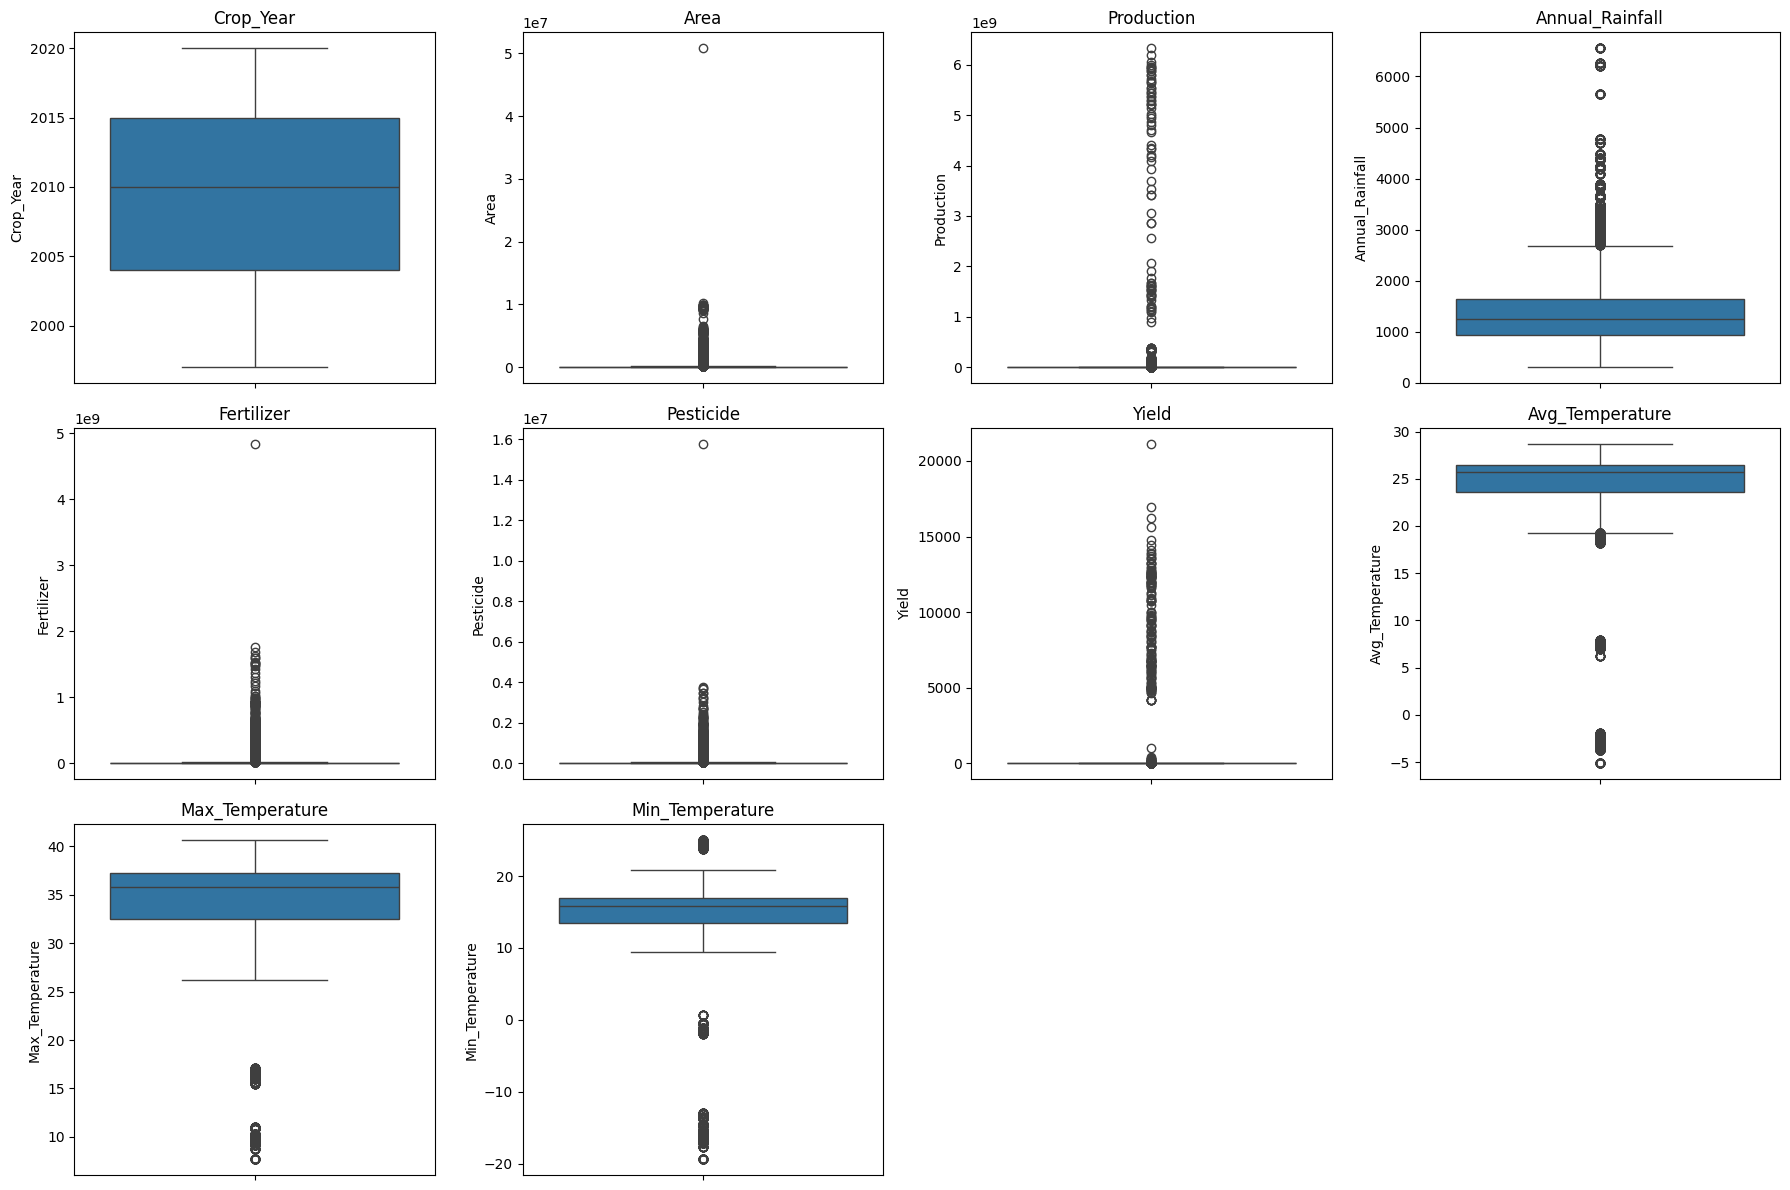

In [17]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(18,12))

for i,col in enumerate(numeric_columns):

    plt.subplot(3,4,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

Find Outliers using IQR method

In [18]:
#Find the Outliers
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower) | (df[col] > upper)]

  print(col, ":", len(outliers))

Crop_Year : 0
Area : 3076
Production : 3373
Annual_Rainfall : 1527
Fertilizer : 3093
Pesticide : 3036
Yield : 3065
Avg_Temperature : 1801
Max_Temperature : 857
Min_Temperature : 1527


Remove Outliers

In [19]:
for col in numeric_columns:

    Q1=df[col].quantile(0.25)

    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    df=df[(df[col]>=lower) & (df[col]<=upper)]

Check Dataset Shape

In [20]:
print(df.shape)

(7605, 13)


Check Skewness

In [21]:
skewness = df[numeric_columns].skew()

print(skewness)

Crop_Year         -0.133815
Area               1.752911
Production         4.001174
Annual_Rainfall    0.509124
Fertilizer         1.924767
Pesticide          1.270556
Yield              1.522848
Avg_Temperature   -0.705546
Max_Temperature   -0.507554
Min_Temperature   -0.014851
dtype: float64


Plot Distribution

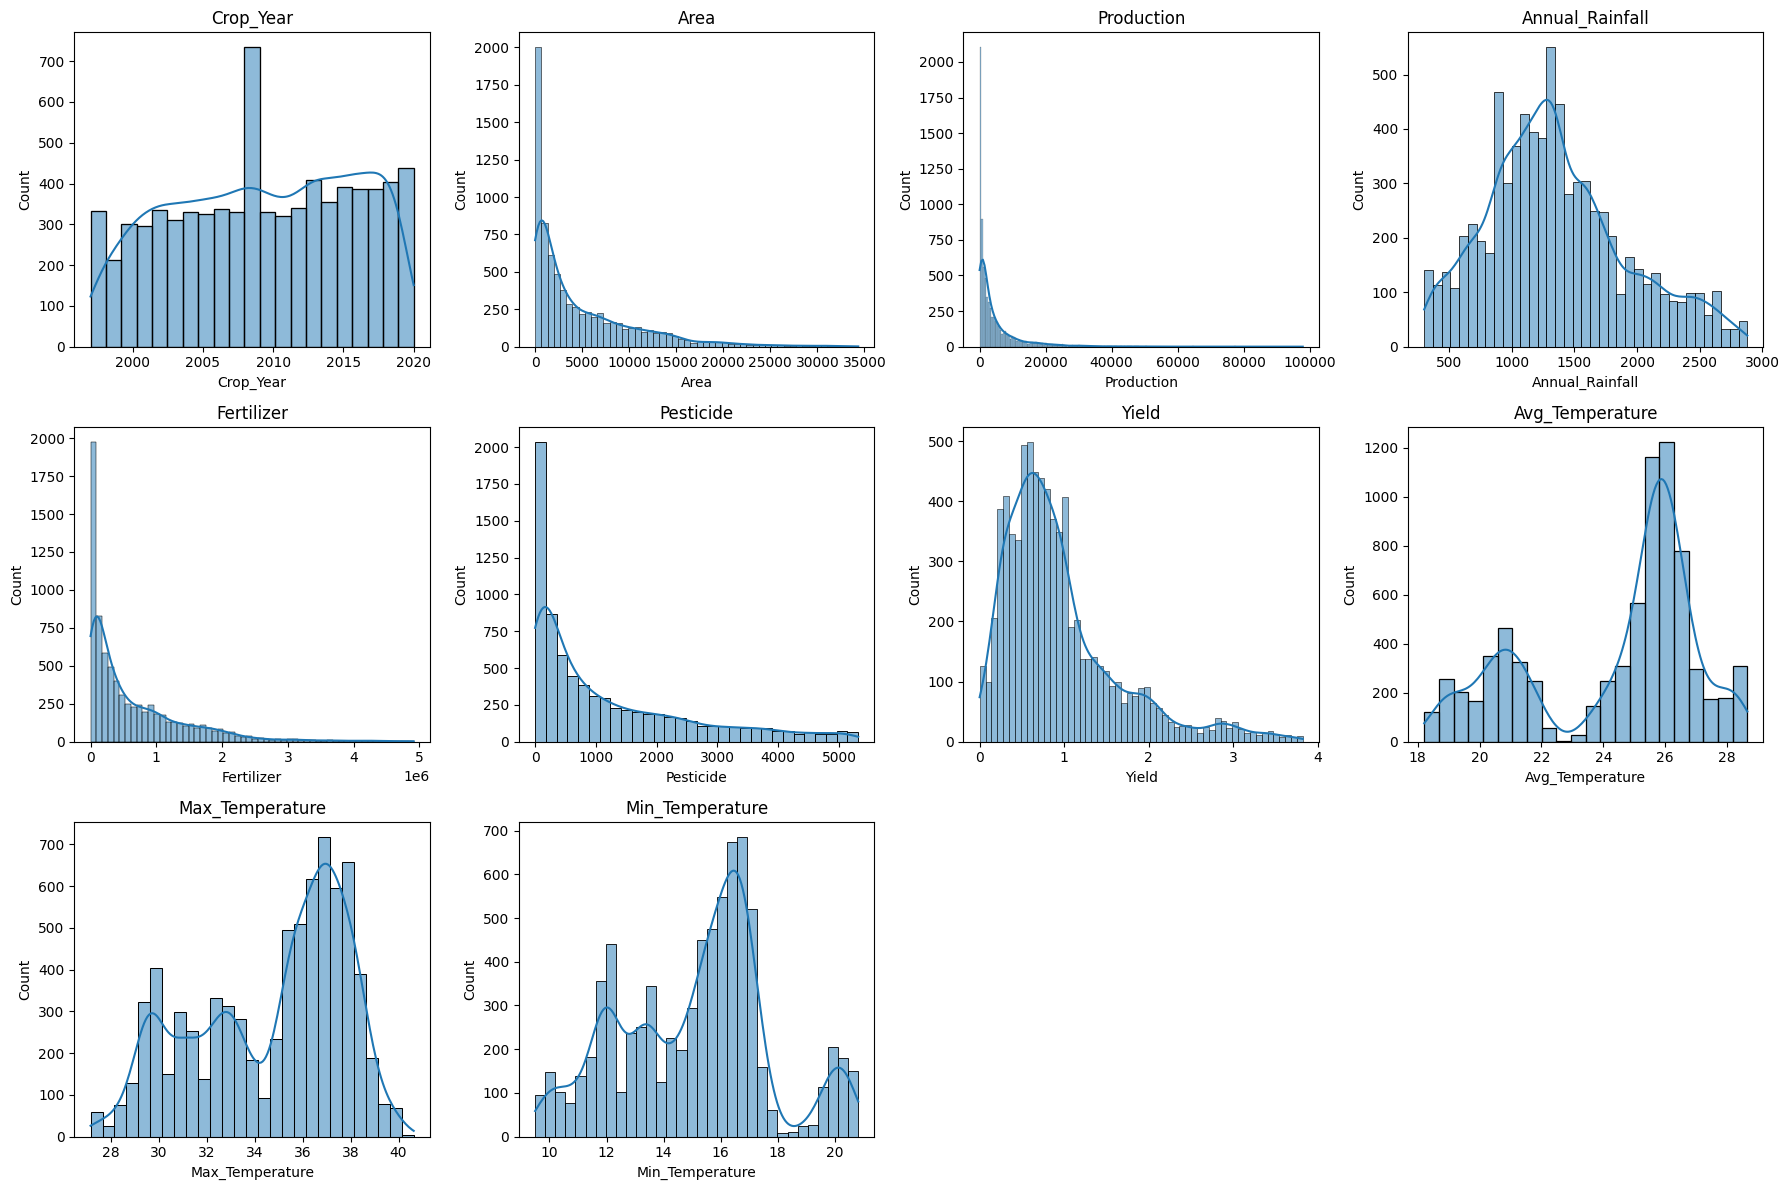

In [22]:
plt.figure(figsize=(18,12))

for i,col in enumerate(numeric_columns):

    plt.subplot(3,4,i+1)

    sns.histplot(df[col],kde=True)

    plt.title(col)

plt.tight_layout()

plt.show()

Handle Skewness

In [23]:
for col in numeric_columns:

    if df[col].min() > 0:

        if abs(df[col].skew())>1:

            df[col]=np.log1p(df[col])

Verify Skewness

In [24]:
df[numeric_columns].skew()

,0
Crop_Year,-0.133815
Area,-1.021262
Production,4.001174
Annual_Rainfall,0.509124
Fertilizer,-1.100735
Pesticide,-0.927302
Yield,1.522848
Avg_Temperature,-0.705546
Max_Temperature,-0.507554
Min_Temperature,-0.014851


Verify Distribution

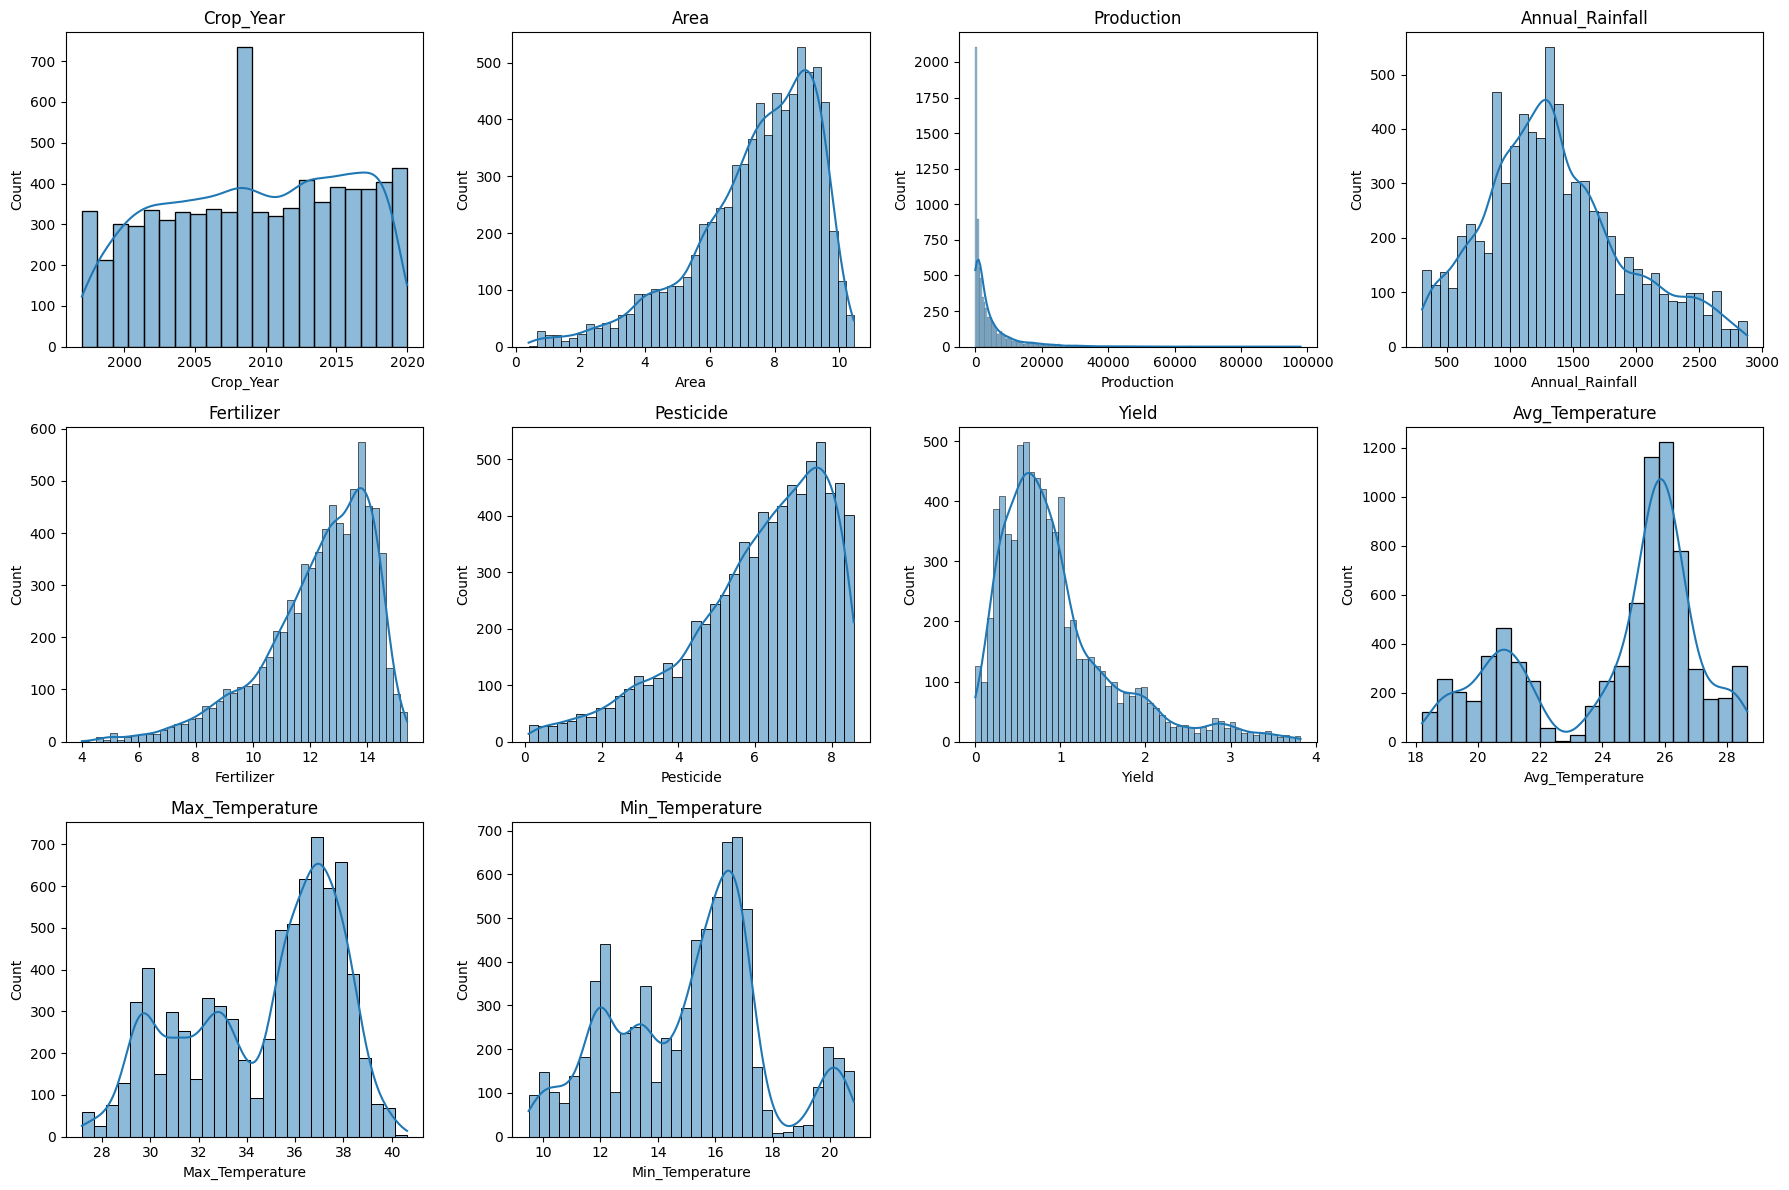

In [25]:
plt.figure(figsize=(18,12))

for i,col in enumerate(numeric_columns):

    plt.subplot(3,4,i+1)

    sns.histplot(df[col],kde=True)

    plt.title(col)

plt.tight_layout()

plt.show()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7605 entries, 1 to 19685
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Crop             7605 non-null   category
 1   Crop_Year        7605 non-null   int64   
 2   Season           7605 non-null   category
 3   State            7605 non-null   category
 4   Area             7605 non-null   float64 
 5   Production       7605 non-null   int64   
 6   Annual_Rainfall  7605 non-null   float64 
 7   Fertilizer       7605 non-null   float64 
 8   Pesticide        7605 non-null   float64 
 9   Yield            7605 non-null   float64 
 10  Avg_Temperature  7605 non-null   float64 
 11  Max_Temperature  7605 non-null   float64 
 12  Min_Temperature  7605 non-null   float64 
dtypes: category(3), float64(8), int64(2)
memory usage: 679.8 KB


In [2]:
df.to_csv("crop_yield_preprocessed.csv",index=False)

print("Preprocessed Dataset Saved Successfully")

NameError: name 'df' is not defined